In [1]:
import nltk

In [2]:
nltk.download('gutenberg')
nltk.download('brown')

[nltk_data] Downloading package gutenberg to
[nltk_data]     C:\Users\harshit.s.p\AppData\Roaming\nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!
[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\harshit.s.p\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!


True

In [3]:
from nltk.corpus import gutenberg,brown,stopwords
from nltk import FreqDist,Text

In [4]:
stop = set(stopwords.words('english'))
gutenberg_words= gutenberg.words()
brown_words=brown.words()


In [5]:

def compute_stats(words, name):
    total = len(words)
    vocab = set(w.lower() for w in words if w.isalpha())
    vocab_size = len(vocab)
    lex_diversity = (vocab_size / total)
    print(f"{name}")
    print(f"Total words     : {total}")
    print(f"Vocabulary size : {vocab_size}")
    print(f"Lexical diversity: {lex_diversity}")

compute_stats(gutenberg_words, "Gutenberg")
compute_stats(brown_words, "Brown")


Gutenberg
Total words     : 2621613
Vocabulary size : 41487
Lexical diversity: 0.015824990187338864
Brown
Total words     : 1161192
Vocabulary size : 40234
Lexical diversity: 0.03464887804945263


In [6]:
def top_words(words, name):
    filtered = [w.lower() for w in words if w.isalpha() and w.lower() not in stop]
    freq = FreqDist(filtered)
    print(f"Top {20} in {name}:", freq.most_common(20))
    return freq

top_words(gutenberg_words, "Gutenberg")
top_words(brown_words, "Brown")


Top 20 in Gutenberg: [('shall', 11682), ('said', 9429), ('unto', 9010), ('lord', 8590), ('thou', 6759), ('one', 6218), ('man', 5615), ('thy', 5609), ('god', 5287), ('thee', 4807), ('ye', 4674), ('upon', 4587), ('would', 4046), ('come', 3642), ('could', 3594), ('like', 3468), ('came', 3337), ('day', 3326), ('king', 3149), ('little', 3065)]
Top 20 in Brown: [('one', 3292), ('would', 2714), ('said', 1961), ('new', 1635), ('could', 1601), ('time', 1598), ('two', 1412), ('may', 1402), ('first', 1361), ('like', 1292), ('man', 1207), ('even', 1170), ('made', 1125), ('also', 1069), ('many', 1030), ('must', 1013), ('af', 996), ('back', 966), ('years', 950), ('much', 937)]


FreqDist({'one': 3292, 'would': 2714, 'said': 1961, 'new': 1635, 'could': 1601, 'time': 1598, 'two': 1412, 'may': 1402, 'first': 1361, 'like': 1292, ...})

In [7]:
gut_text = Text(gutenberg_words)
brown_text = Text(brown_words)

gut_text.concordance("health")
brown_text.concordance("health")

Displaying 25 of 161 matches:
r powers to attach and amuse her in health -- and how nursed her through the v
normous pay might be screwed out of health and into vanity -- but a real , hon
to every thing , his care for their health made him grieve that they would eat
plexion ! oh ! what a bloom of full health , and such a pretty height and size
 firm and upright figure ! There is health , not merely in her bloom , but in 
s of a child being ` the picture of health ;' now , Emma always gives me the i
 the complete picture of grown - up health . She is loveliness itself . Mr . K
stitution ; was delicate in her own health , over - careful of that of her chi
 a mistake , sir .-- We all had our health perfectly well there , never found 
h ! my dear , as Perry says , where health is at stake , nothing else should b
 inquiries after Mr . Woodhouse ' s health , cheerful communications about her
ative air , for the recovery of her health , than on any thing else . Certain 
though a slight appear

In [8]:
print(gutenberg.fileids())

['austen-emma.txt', 'austen-persuasion.txt', 'austen-sense.txt', 'bible-kjv.txt', 'blake-poems.txt', 'bryant-stories.txt', 'burgess-busterbrown.txt', 'carroll-alice.txt', 'chesterton-ball.txt', 'chesterton-brown.txt', 'chesterton-thursday.txt', 'edgeworth-parents.txt', 'melville-moby_dick.txt', 'milton-paradise.txt', 'shakespeare-caesar.txt', 'shakespeare-hamlet.txt', 'shakespeare-macbeth.txt', 'whitman-leaves.txt']


In [ ]:
def compare_authors(name1, file1, name2, file2):
    w1 = Text(gutenberg.words(file1))
    w2 = Text(gutenberg.words(file2))
    
    print(name1)
    print("Vocab size:", len(set(w1)))
    print("Lexical diversity:", (len(set(w1))/len(w1)))
    w1.collocations()
    
    print(name2)
    print("Vocab size:", len(set(w2)))
    print("Lexical diversity:", (len(set(w2))/len(w2)))
    w2.collocations()


compare_authors("Austen - Emma", "austen-emma.txt", "Shakespeare - Hamlet", "shakespeare-hamlet.txt")

<Axes: xlabel='Samples', ylabel='Counts'>

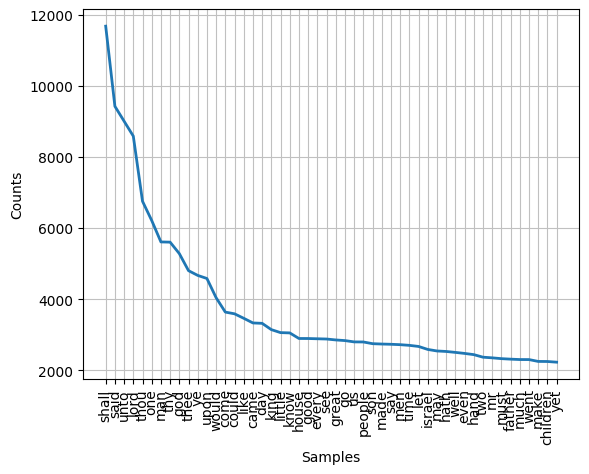

In [ ]:
FreqDist(w.lower() for w in gutenberg_words if w.isalpha() and w.lower() not in stop).plot(50)



<Axes: xlabel='Samples', ylabel='Counts'>

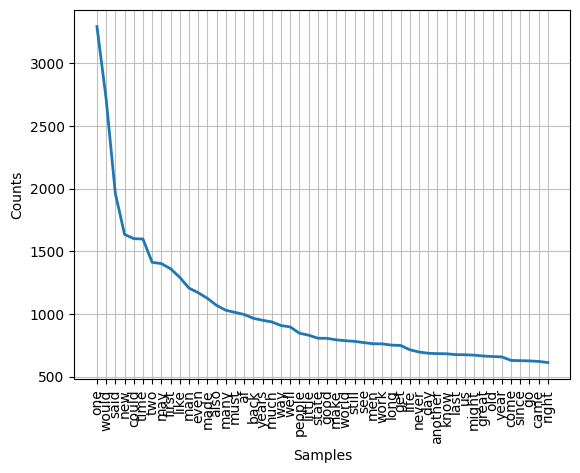

In [ ]:
FreqDist(w.lower() for w in brown_words if w.isalpha() and w.lower() not in stop).plot(50)

Observations : 

1.Brown Corpus has higher lexical diversity,it has almost similair vocab size compared to Gutenberg even though gutenberg has roughly 2x more words.

2.Higher Lexical diversity means writing is much more richer indicating less repition 



Question - 2


In [ ]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import FreqDist, pos_tag

In [ ]:
with open("Cricket.txt", "r") as f:
    raw_text = f.read()

In [ ]:
def preprocess_text(text):
    sentences = sent_tokenize(text)
    words = word_tokenize(text.lower())
    
    stop = set(stopwords.words('english'))
    words = [w for w in words if w.isalpha() and w not in stop]
    
    stemmer = PorterStemmer()
    stemmed = [stemmer.stem(w) for w in words]
    
    lemmatizer = WordNetLemmatizer()
    lemmatized = [lemmatizer.lemmatize(w) for w in words]
    
    return sentences, words, stemmed, lemmatized

sentences, words, stemmed, lemmatized = preprocess_text(raw_text)

print("Total sentences:", len(sentences))
print("Total words after cleaning:", len(words))
print("Sample words:", words[:10])
print("Sample stemmed:", stemmed[:10])
print("Sample lemmatized:", lemmatized[:10])


Total sentences: 132
Total words after cleaning: 1909
Sample words: ['cricket', 'game', 'played', 'two', 'teams', 'eleven', 'players', 'field', 'centre', 'pitch']
Sample stemmed: ['cricket', 'game', 'play', 'two', 'team', 'eleven', 'player', 'field', 'centr', 'pitch']
Sample lemmatized: ['cricket', 'game', 'played', 'two', 'team', 'eleven', 'player', 'field', 'centre', 'pitch']


<Axes: title={'center': 'Top 30 Words - Cricket'}, xlabel='Samples', ylabel='Counts'>

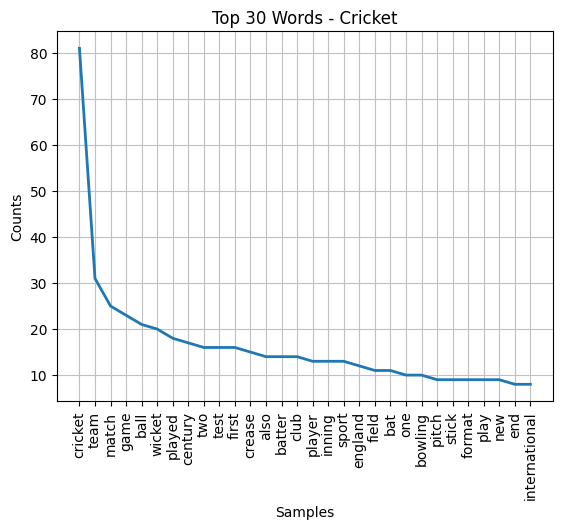

In [ ]:
FreqDist(lemmatized).plot(30, title="Top 30 Words - Cricket")


Question - 3 

In [ ]:
import requests
import re
from bs4 import BeautifulSoup


In [ ]:
import requests

url = "https://en.wikipedia.org/wiki/Cricket"
response = requests.get(url)
html_text = response.text



In [ ]:
def extract_emails(text):
    return re.findall(r'[\w.+-]+@[\w-]+\.[a-z]{2,}', text)

def extract_urls(text):
     return re.findall(r'https?://[^\s<>"\']+', text)

emails = extract_emails(html_text)
urls = extract_urls(html_text)

print("Emails found:", emails)
print("Total URLs found:", len(urls))



Emails found: []
Total URLs found: 2
Sample URLs: ['https://w.wiki/4wJS.', 'https://phabricator.wikimedia.org/T400119.']


In [ ]:
def clean_html(text):
    return BeautifulSoup(text, "html.parser").get_text()

def remove_urls(text):
    return re.sub(r'https?://[^\s<>"\']+', '', text)

def remove_emails(text):
    return re.sub(r'[\w.+-]+@[\w-]+\.[a-z]{2,}', '', text)

def remove_numbers(text):
    return re.sub(r'\d+', '', text)

def remove_special_chars(text):
    return re.sub(r'[^a-zA-Z\s]', '', text)

def normalize_text(text):
    stop = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    words = text.lower().split()
    words = [lemmatizer.lemmatize(w) for w in words if w.isalpha() and w not in stop]
    return ' '.join(words)


In [ ]:
def cleaning_pipeline(text):
    emails = extract_emails(text)
    urls = extract_urls(text)

    text = clean_html(text)
    text = remove_urls(text)
    text = remove_emails(text)
    text = remove_numbers(text)
    text = remove_special_chars(text)
    text = normalize_text(text)

    return text, emails, urls

cleaned, emails, urls = cleaning_pipeline(html_text)

print("Extracted emails:", emails)
print("Total URLs extracted:", len(urls))



Extracted emails: []
Total URLs extracted: 2
Sample URLs: ['https://w.wiki/4wJS.', 'https://phabricator.wikimedia.org/T400119.']
Cleaned text sample: please set useragent respect robot policy see also


In [ ]:

import json
from nltk import pos_tag, RegexpParser,ne_chunk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import treebank
from nltk.tag import UnigramTagger

nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('treebank')
nltk.download('punkt')


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\harshit.s.p\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     C:\Users\harshit.s.p\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\harshit.s.p\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package treebank to
[nltk_data]     C:\Users\harshit.s.p\AppData\Roaming\nltk_data...
[nltk_data]   Package treebank is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\harshit.s.p\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
resume_text = """
John Smith is a Software Engineer at Google in New York.
He has experience working at Microsoft and Amazon in Seattle.
His skills include Python, Machine Learning, Deep Learning, Data Analysis,
TensorFlow, NLP, and Cloud Computing.
He studied at MIT and lives in San Francisco, California.
"""


In [ ]:
def extract_named_entities(text):
    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)
    chunked = ne_chunk(tagged)

    names, orgs, locations = [], [], []
    for subtree in chunked:
        if hasattr(subtree, 'label'):
            entity = ' '.join(w for w, t in subtree.leaves())
            if subtree.label() == 'PERSON':
                names.append(entity)
            elif subtree.label() == 'ORGANIZATION':
                orgs.append(entity)
            elif subtree.label() == 'GPE':
                locations.append(entity)

    return names, orgs, locations


def extract_skills(text):
    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)
    grammar = "NP: {<JJ>*<NN.*>+}"
    parser = RegexpParser(grammar)
    tree = parser.parse(tagged)
    return [' '.join(w for w, t in subtree.leaves())
            for subtree in tree.subtrees() if subtree.label() == 'NP']


def extract_resume_info(text):
    names, orgs, locations = extract_named_entities(text)
    skills = extract_skills(text)
    return {
        "name": names[0] if names else "",
        "organizations": orgs,
        "skills": skills,
        "locations": locations
    }


info = extract_resume_info(resume_text)
print(json.dumps(info, indent=2))


In [ ]:
def compare_taggers():
    data = treebank.tagged_sents()
    train, test = data[:3000], data[3000:]

    unigram = UnigramTagger(train)
    unigram_acc = unigram.accuracy(test)

    test_sents = [[w for w, t in sent] for sent in test]
    gold_tags = [t for sent in test for w, t in sent]
    pred_tags = [t for sent in test_sents for w, t in pos_tag(sent)]
    default_acc = sum(p == g for p, g in zip(pred_tags, gold_tags)) / len(gold_tags)

    print(f"Default POS Tagger : {default_acc:.4f}")
    print(f"Unigram Tagger     : {unigram_acc:.4f}")

compare_taggers()
